<a href="https://colab.research.google.com/github/7amokarim/breast-cancer-detection-system/blob/main/Unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"

In [ ]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

images = []
masks = []

for cls in ["benign", "malignant"]:
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):
        if "_mask" not in file:
            img_path = os.path.join(folder, file)
            mask_path = img_path.replace(".png", "_mask.png")

            if not os.path.exists(mask_path):
                continue

            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

            mask = cv2.imread(mask_path, 0)
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print(images.shape, masks.shape)

(647, 224, 224, 3) (647, 224, 224, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras import layers, Model

def unet(input_size=(224,224,3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(256,3,activation='relu',padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(128,3,activation='relu',padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(64,3,activation='relu',padding='same')(u2)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)

    return Model(inputs, outputs)

model = unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 112, 112,  │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112, 112,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 224, 224,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 224, 224,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 224, 224,  │         65 │ conv2d_6[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,108,545 (4.23 MB)

 Trainable params: 1,108,545 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=16
)

Epoch 1/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 1421s 43s/step - accuracy: 0.8837 - loss: 0.3563 - val_accuracy: 0.8942 - val_loss: 0.3388
Epoch 2/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 1406s 43s/step - accuracy: 0.9086 - loss: 0.2907 - val_accuracy: 0.8942 - val_loss: 0.3236
Epoch 3/3
33/33 ━━━━━━━━━━━━━━━━━━━━ 1397s 42s/step - accuracy: 0.9086 - loss: 0.2830 - val_accuracy: 0.8942 - val_loss: 0.3053


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


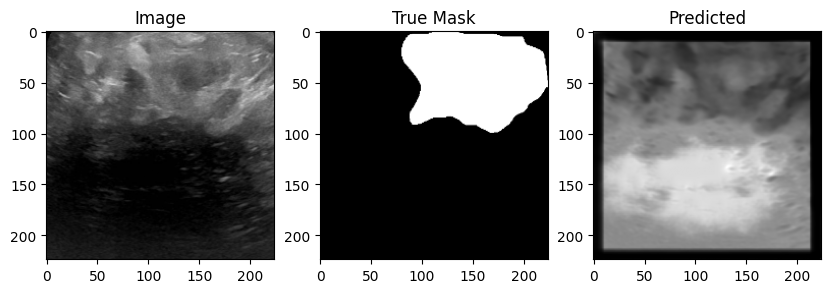

In [ ]:
import matplotlib.pyplot as plt

pred = model.predict(X_val[:3])

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(X_val[0])

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(y_val[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(pred[0].squeeze(), cmap='gray')

In [ ]:
model.save("unet_model.keras")

In [ ]:
from google.colab import files
files.download("unet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>